In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:


df_raw = pd.read_csv("merged_pressure_data.csv")

print("Shape:", df_raw.shape)
print("Sol range:", df_raw["sol"].min(), "to", df_raw["sol"].max())
print("Unique sols:", df_raw["sol"].nunique())

Shape: (6607361, 11)
Sol range: 1.0 to 429.0
Unique sols: 143


In [ ]:
df = pd.read_csv("merged_pressure_data.csv")

print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 6607361
Duplicate rows: 0


In [ ]:


df.replace(9999999999, np.nan, inplace=True)

df = df.dropna(subset=["BAROCAP1_PRESSURE"])

print("Sol Range:", df["sol"].min(), "to", df["sol"].max())
print("Total unique sols:", df["sol"].nunique())

Sol Range: 1.0 to 429.0
Total unique sols: 143


In [ ]:
print(df.shape)
print(df["sol"].nunique())

(6607360, 11)
143


In [ ]:
sol_pressure = df.groupby("sol")["BAROCAP1_PRESSURE"].mean().reset_index()

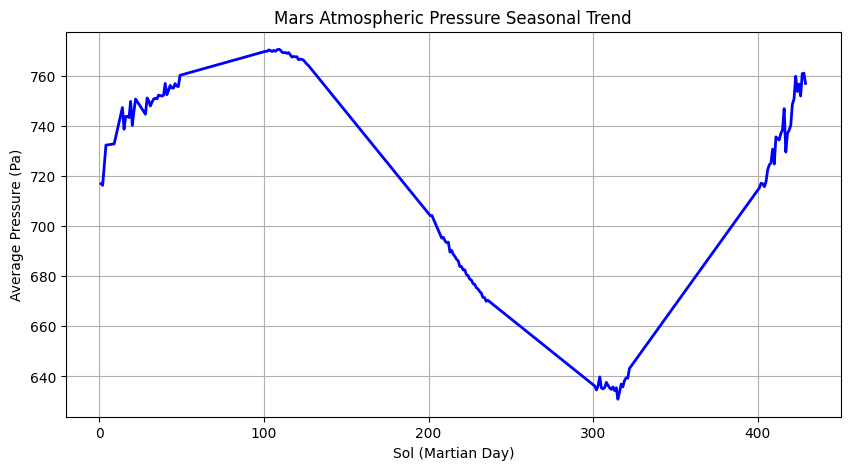

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(sol_pressure["sol"],
         sol_pressure["BAROCAP1_PRESSURE"],
         color="blue",
         linewidth=2)

plt.xlabel("Sol (Martian Day)")
plt.ylabel("Average Pressure (Pa)")
plt.title("Mars Atmospheric Pressure Seasonal Trend")

plt.grid(True)

plt.show()

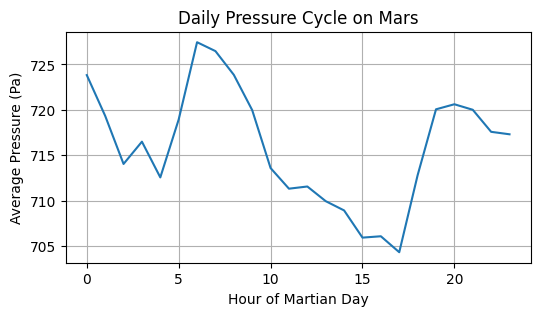

In [ ]:
df["hour"] = df["LMST"].str.split("M").str[1].str.split(":").str[0].astype(int)

hourly_pressure = df.groupby("hour")["BAROCAP1_PRESSURE"].mean()

plt.figure(figsize=(6,3))

plt.plot(hourly_pressure)

plt.xlabel("Hour of Martian Day")
plt.ylabel("Average Pressure (Pa)")
plt.title("Daily Pressure Cycle on Mars")

plt.grid(True)

plt.show()

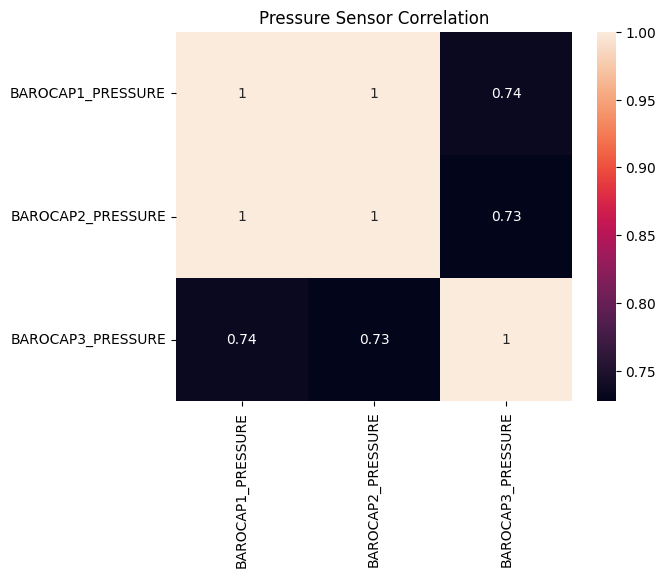

<Figure size 500x500 with 0 Axes>

In [ ]:
import seaborn as sns

corr = df[[
    "BAROCAP1_PRESSURE",
    "BAROCAP2_PRESSURE",
    "BAROCAP3_PRESSURE"
]].corr()

sns.heatmap(corr, annot=True)

plt.title("Pressure Sensor Correlation")
plt.figure(figsize=(5,5))

plt.show()

In [ ]:
df["pressure_change"] = df["BAROCAP1_PRESSURE"].diff()

threshold = df["pressure_change"].mean() - 3*df["pressure_change"].std()

storms = df[df["pressure_change"] < threshold]

print("Number of potential storm events:", len(storms))

Number of potential storm events: 2029


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


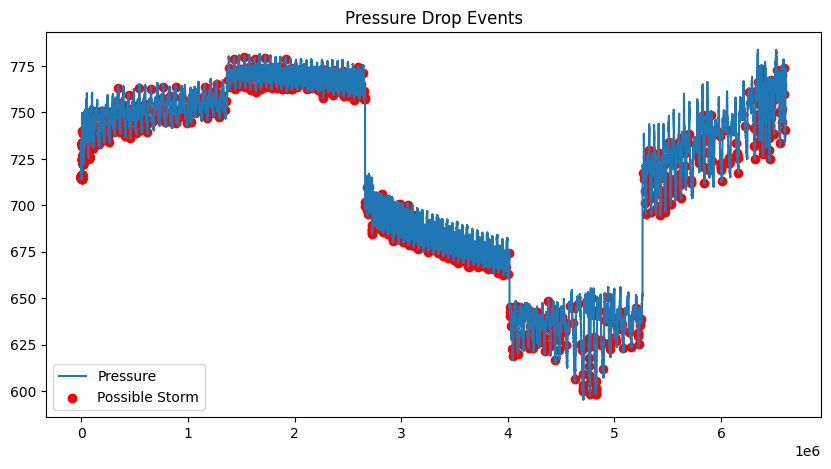

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["BAROCAP1_PRESSURE"], label="Pressure")

plt.scatter(storms.index,
            storms["BAROCAP1_PRESSURE"],
            color="red",
            label="Possible Storm")

plt.legend()
plt.title("Pressure Drop Events")

plt.show()

In [ ]:
df["hour"] = df["LMST"].str.split("M").str[1].str.split(":").str[0].astype(int)

In [ ]:
hourly_pressure = df.groupby(["sol","hour"])["BAROCAP1_PRESSURE"].mean().reset_index()

In [ ]:
hourly_pressure["time_index"] = range(len(hourly_pressure))

In [ ]:
hourly_pressure["pressure_change"] = hourly_pressure["BAROCAP1_PRESSURE"].diff()

In [ ]:
mean_change = hourly_pressure["pressure_change"].mean()
std_change = hourly_pressure["pressure_change"].std()

threshold = mean_change - 2.5 * std_change

storms = hourly_pressure[hourly_pressure["pressure_change"] < threshold]

print("Detected storm events:", len(storms))

Detected storm events: 23


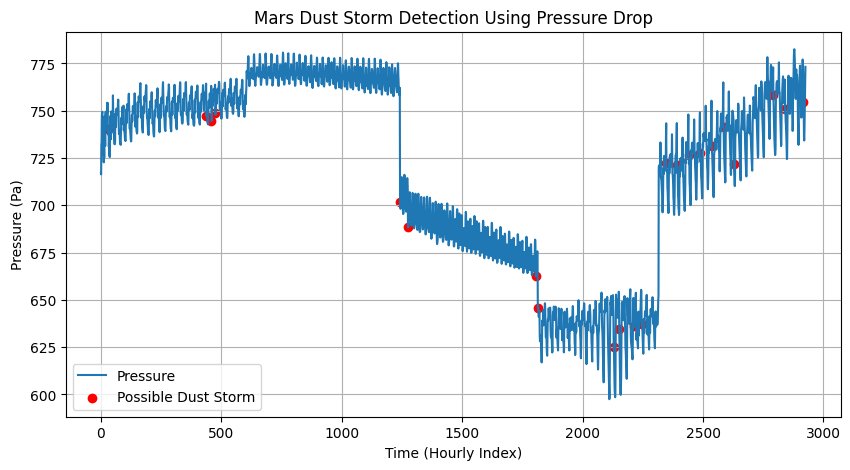

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(hourly_pressure["time_index"],
         hourly_pressure["BAROCAP1_PRESSURE"],
         label="Pressure")

plt.scatter(storms["time_index"],
            storms["BAROCAP1_PRESSURE"],
            color="red",
            label="Possible Dust Storm")

plt.xlabel("Time (Hourly Index)")
plt.ylabel("Pressure (Pa)")
plt.title("Mars Dust Storm Detection Using Pressure Drop")

plt.legend()
plt.grid(True)

plt.show()

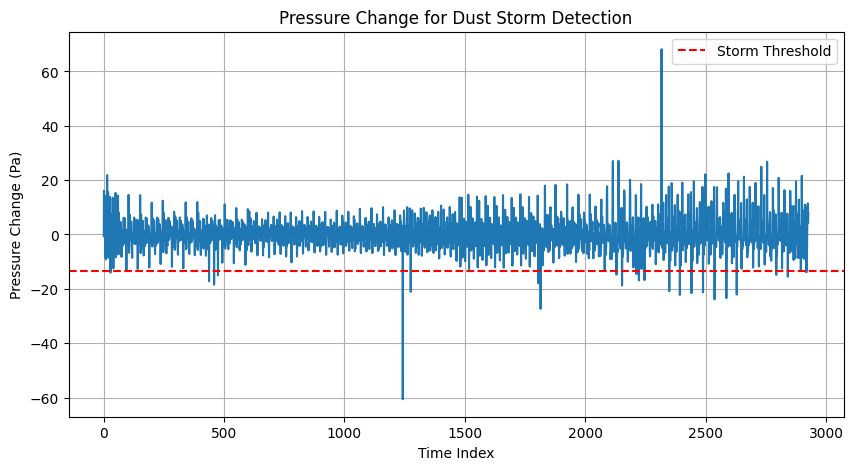

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(hourly_pressure["pressure_change"])

plt.axhline(threshold, color="red", linestyle="--", label="Storm Threshold")

plt.title("Pressure Change for Dust Storm Detection")

plt.xlabel("Time Index")
plt.ylabel("Pressure Change (Pa)")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

In [ ]:
hourly = df.groupby(["sol","hour"])["BAROCAP1_PRESSURE"].mean().reset_index()

# create time index
hourly["time_index"] = range(len(hourly))

In [ ]:
scaler = MinMaxScaler()

pressure_scaled = scaler.fit_transform(hourly[["BAROCAP1_PRESSURE"]])

In [ ]:
def create_sequences(data, seq_len):
    X, y = [], []

    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])

    return np.array(X), np.array(y)

seq_length = 24

X, y = create_sequences(pressure_scaled, seq_length)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
lstm_model = Sequential()

lstm_model.add(LSTM(50, input_shape=(seq_length,1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0253 - val_loss: 0.0052
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 0.0052
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0025 - val_loss: 0.0052
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0051
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0050
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0023 - val_loss: 0.0049
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0023 - val_loss: 0.0049
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0022 - val_loss: 0.0047
Epoch 9/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0022 - val_loss: 0.0046
Epoch 10/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 0.0045
Epoch 11/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0043
Epoch 12/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_

In [ ]:
gru_model = Sequential()

gru_model.add(GRU(50, input_shape=(seq_length,1)))
gru_model.add(Dense(1))

gru_model.compile(optimizer="adam", loss="mse")

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0494 - val_loss: 0.0037
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - val_loss: 0.0032
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - val_loss: 0.0030
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 0.0027
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 0.0023
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 0.0023
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0020
Epoch 9/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 10/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 11/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 0.0019
Epoch 12/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0010 - val_lo

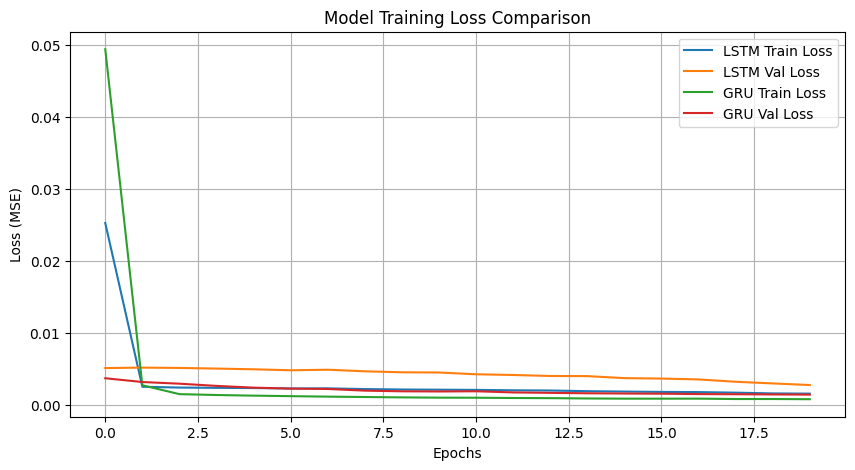

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(lstm_history.history["loss"], label="LSTM Train Loss")
plt.plot(lstm_history.history["val_loss"], label="LSTM Val Loss")

plt.plot(gru_history.history["loss"], label="GRU Train Loss")
plt.plot(gru_history.history["val_loss"], label="GRU Val Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Model Training Loss Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
y_test_actual = scaler.inverse_transform(y_test)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
gru_pred_actual = scaler.inverse_transform(gru_pred)

In [ ]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100

    return mae, rmse, r2, mape

lstm_results = evaluate(y_test_actual, lstm_pred_actual)
gru_results = evaluate(y_test_actual, gru_pred_actual)

print("LSTM:", lstm_results)
print("GRU :", gru_results)

LSTM: (8.297643511477265, np.float64(9.799504209261116), 0.7333043196566702, np.float64(1.1240548344116394))
GRU : (5.49202686170333, np.float64(7.099159849586973), 0.860034279457245, np.float64(0.7440555981856332))


In [ ]:
results = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MAE": [lstm_results[0], gru_results[0]],
    "RMSE": [lstm_results[1], gru_results[1]],
    "R2 Score": [lstm_results[2], gru_results[2]],
    "MAPE (%)": [lstm_results[3], gru_results[3]]
})

print(results)

  Model       MAE      RMSE  R2 Score  MAPE (%)
0  LSTM  8.297644  9.799504  0.733304  1.124055
1   GRU  5.492027  7.099160  0.860034  0.744056


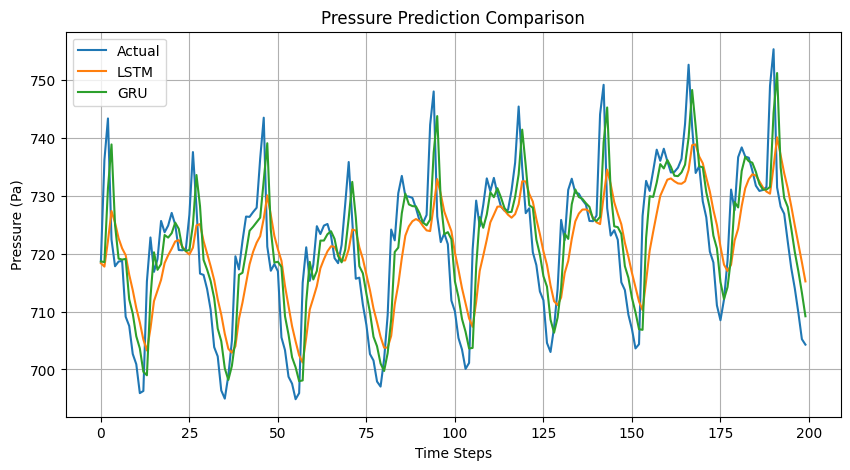

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual[:200], label="Actual")

plt.plot(lstm_pred_actual[:200], label="LSTM")

plt.plot(gru_pred_actual[:200], label="GRU")

plt.xlabel("Time Steps")
plt.ylabel("Pressure (Pa)")
plt.title("Pressure Prediction Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [37]:
def predict_future(model, data_scaled, seq_length, steps):
    future = []
    current_seq = data_scaled[-seq_length:]

    for _ in range(steps):
        pred = model.predict(current_seq.reshape(1, seq_length, 1), verbose=0)
        future.append(pred[0][0])
        current_seq = np.append(current_seq[1:], pred)

    return scaler.inverse_transform(np.array(future).reshape(-1,1))

In [38]:
future_steps = 24

lstm_future = predict_future(lstm_model, pressure_scaled, seq_length, future_steps)
gru_future = predict_future(gru_model, pressure_scaled, seq_length, future_steps)

# Actual future values
future_actual = hourly["BAROCAP1_PRESSURE"].values[-future_steps:]

In [40]:
evaluate(future_actual, lstm_future)
evaluate(future_actual, gru_future)

(10.688967589360615,
 np.float64(13.189905026660787),
 -0.06816322989465795,
 np.float64(1.4995017366086676))

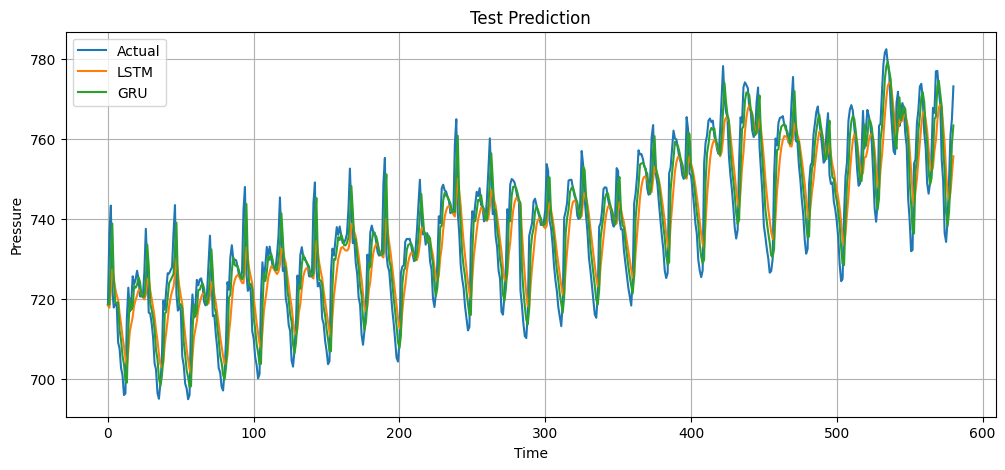

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_pred_actual, label='LSTM')
plt.plot(gru_pred_actual, label='GRU')

plt.title("Test Prediction")
plt.xlabel("Time")
plt.ylabel("Pressure")
plt.legend()
plt.grid()
plt.show()

In [44]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D

# =============================
# CNN-LSTM
# =============================
cnn_lstm = Sequential()

cnn_lstm.add(Conv1D(filters=64,
                    kernel_size=3,
                    activation='relu',
                    input_shape=(seq_length,1)))

cnn_lstm.add(MaxPooling1D(pool_size=2))

cnn_lstm.add(LSTM(50))

cnn_lstm.add(Dense(1))

cnn_lstm.compile(optimizer='adam', loss='mse')

cnn_lstm_history = cnn_lstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# =============================
# CNN-GRU
# =============================
cnn_gru = Sequential()

cnn_gru.add(Conv1D(filters=64,
                   kernel_size=3,
                   activation='relu',
                   input_shape=(seq_length,1)))

cnn_gru.add(MaxPooling1D(pool_size=2))

cnn_gru.add(GRU(50))

cnn_gru.add(Dense(1))

cnn_gru.compile(optimizer='adam', loss='mse')

cnn_gru_history = cnn_gru.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0412 - val_loss: 0.0054
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - val_loss: 0.0051
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0049
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0045
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 0.0040
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0020 - val_loss: 0.0034
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 0.0029
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - val_loss: 0.0026
Epoch 9/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0013 - val_loss: 0.0021
Epoch 10/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 11/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 12/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_l

In [45]:
cnn_lstm_pred = cnn_lstm.predict(X_test)
cnn_gru_pred  = cnn_gru.predict(X_test)

cnn_lstm_pred_actual = scaler.inverse_transform(cnn_lstm_pred)
cnn_gru_pred_actual  = scaler.inverse_transform(cnn_gru_pred)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [46]:
cnn_lstm_results = evaluate(y_test_actual, cnn_lstm_pred_actual)
cnn_gru_results  = evaluate(y_test_actual, cnn_gru_pred_actual)

print("CNN-LSTM :", cnn_lstm_results)
print("CNN-GRU  :", cnn_gru_results)

CNN-LSTM : (4.827036886308416, np.float64(6.543837589613543), 0.8810750991121482, np.float64(0.6549822685403871))
CNN-GRU  : (5.868679666971436, np.float64(7.611126359129981), 0.839118673614066, np.float64(0.7983734138370349))


In [48]:
results = pd.DataFrame({
    "Model": ["LSTM", "GRU", "CNN-LSTM", "CNN-GRU"],

    "MAE": [
        lstm_results[0],
        gru_results[0],
        cnn_lstm_results[0],
        cnn_gru_results[0]
    ],

    "RMSE": [
        lstm_results[1],
        gru_results[1],
        cnn_lstm_results[1],
        cnn_gru_results[1]
    ],

    "R2 Score": [
        lstm_results[2],
        gru_results[2],
        cnn_lstm_results[2],
        cnn_gru_results[2]
    ],

    "MAPE (%)": [
        lstm_results[3],
        gru_results[3],
        cnn_lstm_results[3],
        cnn_gru_results[3]
    ]
})

print(results)

      Model       MAE      RMSE  R2 Score  MAPE (%)
0      LSTM  8.297644  9.799504  0.733304  1.124055
1       GRU  5.492027  7.099160  0.860034  0.744056
2  CNN-LSTM  4.827037  6.543838  0.881075  0.654982
3   CNN-GRU  5.868680  7.611126  0.839119  0.798373


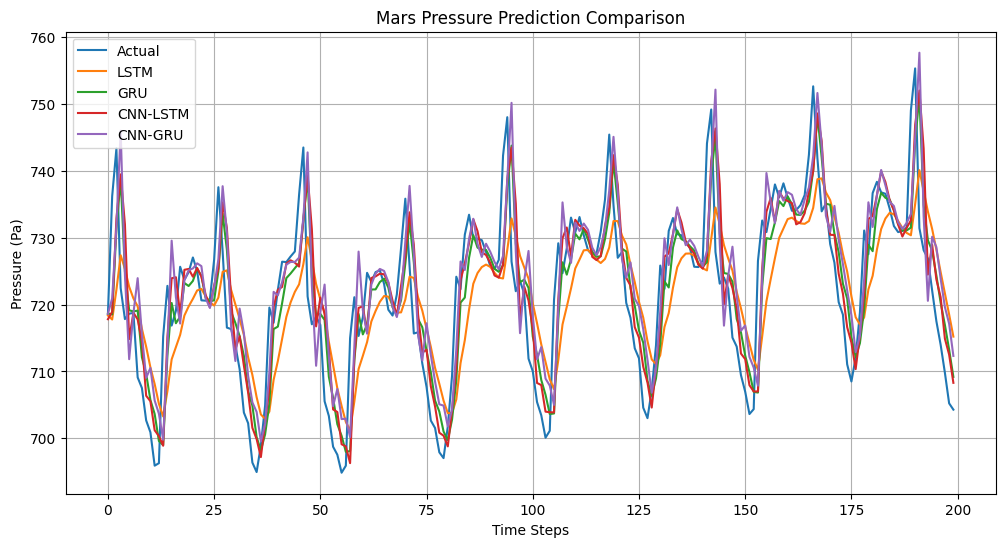

In [49]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual[:200], label="Actual")

plt.plot(lstm_pred_actual[:200], label="LSTM")
plt.plot(gru_pred_actual[:200], label="GRU")
plt.plot(cnn_lstm_pred_actual[:200], label="CNN-LSTM")
plt.plot(cnn_gru_pred_actual[:200], label="CNN-GRU")

plt.title("Mars Pressure Prediction Comparison")
plt.xlabel("Time Steps")
plt.ylabel("Pressure (Pa)")
plt.legend()
plt.grid(True)
plt.show()

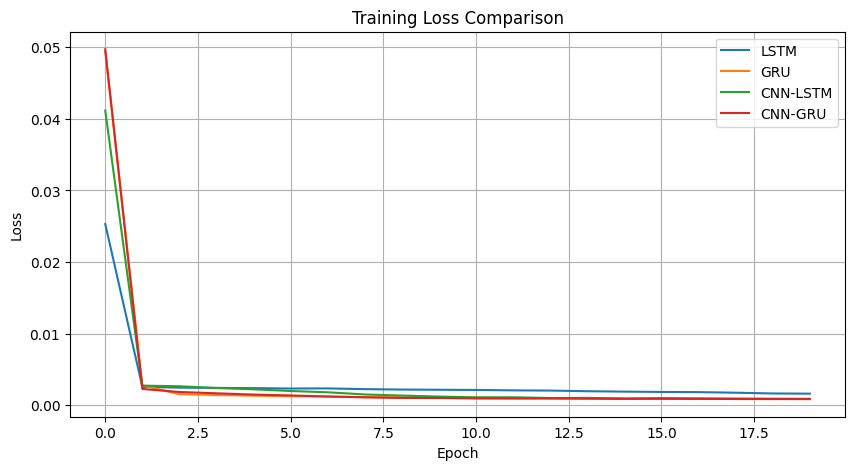

In [50]:
plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.plot(cnn_lstm_history.history['loss'], label='CNN-LSTM')
plt.plot(cnn_gru_history.history['loss'], label='CNN-GRU')

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

    Future_Hour  Predicted_Pressure(Pa)
0             1              767.122681
1             2              768.425415
2             3              767.559387
3             4              766.541260
4             5              764.530762
5             6              762.091614
6             7              759.808777
7             8              757.734375
8             9              757.457092
9            10              757.571472
10           11              759.150085
11           12              760.481384
12           13              762.841980
13           14              763.764832
14           15              764.302795
15           16              763.137268
16           17              761.282104
17           18              758.256104
18           19              755.192993
19           20              752.941040
20           21              751.985474
21           22              752.340576
22           23              753.641541
23           24              755.205444


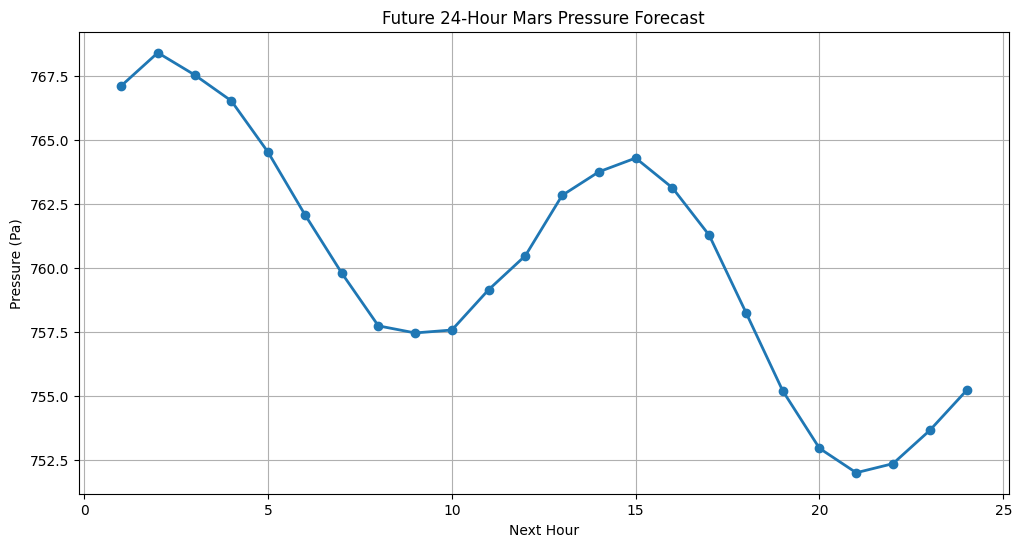

In [52]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model = cnn_lstm


last_sequence = X[-1].copy()     # shape (24,1)

future_predictions = []

current_seq = last_sequence.copy()

for i in range(24):

    # predict next hour
    pred = model.predict(current_seq.reshape(1, seq_length, 1), verbose=0)

    # store prediction
    future_predictions.append(pred[0,0])

    # update sequence:

    current_seq = np.vstack([current_seq[1:], pred])

# ------------------------------------------
# Convert back to original pressure scale
# ------------------------------------------
future_predictions = np.array(future_predictions).reshape(-1,1)

future_predictions_actual = scaler.inverse_transform(future_predictions)

# ------------------------------------------
# Create Hour Labels
# ------------------------------------------
hours = np.arange(1,25)

future_df = pd.DataFrame({
    "Future_Hour": hours,
    "Predicted_Pressure(Pa)": future_predictions_actual.flatten()
})

print(future_df)

# ------------------------------------------
# Plot Future 24-Hour Forecast
# ------------------------------------------
plt.figure(figsize=(12,6))

plt.plot(hours,
         future_predictions_actual,
         marker='o',
         linewidth=2)

plt.title("Future 24-Hour Mars Pressure Forecast")
plt.xlabel("Next Hour")
plt.ylabel("Pressure (Pa)")
plt.grid(True)

plt.show()